# Đánh giá điểm tín dụng sử dụng Decision Tree và Random Forest


Mục tiêu:

- Xây dựng mô hình Decision Tree và Random Forest sử dụng thư viện sklearn.
- Ứng dụng, hiểu cách áp dụng hai mô hình để giải bài toán thực tế (vd: đánh gia điểm tín dụng).
- Sử dụng độ đo thích hợp để đánh giá chất lượng mô hình.

Vấn đề:

- Yếu tố then chốt trong việc cho vay tín dụng là khả năng hoàn trả của người vay. Vì vậy đánh giá điểm tín dụng của người dùng là một bài toán được quan tâm trong lĩnh vực tài chính. Nhìn chung, đây là một bài toán phân lọai 2 lớp (good/bad score).
- Hơn nữa, số lượng bad credits thường ít hơn nhiều so với số lượng good credits ==> Dữ liệu nhãn lớp mất cân bằng.

Dữ liệu:

- Thường ở dưới dạng bảng, mỗi hàng là một cá nhân vay, mỗi cột thể hiện một thuộc tính của cá nhân đó.
- Các trường thuộc tính tồn tại ở nhiều dạng: categorical, numeric (discrete / continuous). Thậm chí tên trường có thể được ẩn đi, hay giá trị thật sự được mã hõa để đảm bảo tính bảo mật của khách hàng.
- Hai tập dữ liệu sẽ sử dụng: German credit và Australian credit.

https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)

https://archive.ics.uci.edu/ml/datasets/Statlog+(German+Credit+Data)

Bài toán:

- Đầu vào: N vector D chiều, tương ứng N cá thể với D thuộc tính.
- Đầu ra: nhãn 0-1 (0: bad credit, 1: good credit).

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

## 1. Tìm hiểu dữ liệu

In [ ]:
data_path = './german.data-numeric'
credit=np.genfromtxt(data_path)
X,y = credit[:,:-1], credit[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print("Data loaded. X_train shape:", X_train.shape)

Data loaded. X_train shape: (800, 24)


## 2. Tìm hiểu mô hình Decision Tree, Random Forest của Sklearn

In [ ]:
DT = DecisionTreeClassifier(random_state=random_state)
RF = RandomForestClassifier(random_state=random_state)

In [ ]:
print('Demo DT and RF prediction')
DT.fit(X_train, y_train)
y_dt_pred = DT.predict(X_test)
print("-DT acc = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT f1 = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

Demo DT and RF prediction
-DT acc = 0.665
-DT f1 = 0.7632508833922261
-DT roc auc = 0.5948431301839163
[[108  33]
 [ 34  25]]


### Bài 1: Chạy RF baseline

In [ ]:
print('Baseline Random Forest Prediction')
RF.fit(X_train, y_train)
y_rf_pred = RF.predict(X_test)
print("-RF acc = {}".format(accuracy_score(y_test, y_rf_pred)))
print("-RF f1 = {}".format(f1_score(y_test, y_rf_pred)))
print("-RF roc auc = {}".format(roc_auc_score(y_test, y_rf_pred)))
print(confusion_matrix(y_test, y_rf_pred))

Baseline Random Forest Prediction
-RF acc = 0.81
-RF f1 = 0.875
-RF roc auc = 0.7173939175381656
[[133   8]
 [ 30  29]]


## 3. Tìm kiếm siêu tham số

In [ ]:
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == "decision-tree":
        model = DecisionTreeClassifier(random_state=random_state)
    if algorithm == "random-forest":
        model = RandomForestClassifier(random_state=random_state)
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring="f1")
    classifier.fit(X_train, y_train)
    print("Best model:", classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model):
    y_tr_pred = model.predict(X_train)
    y_ts_pred = model.predict(X_test)
    print("Train Accuracy :", accuracy_score(y_train, y_tr_pred))
    print("Train f1 score :", f1_score(y_train, y_tr_pred))
    print("Train roc auc :", roc_auc_score(y_train, y_tr_pred))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, y_ts_pred))
    print("Test f1 score :", f1_score(y_test, y_ts_pred))
    print("Test roc auc :", roc_auc_score(y_test, y_ts_pred))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False):
    if new_plot:
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score (F1)")
        plt.grid()
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, test_scores_mean, "o-", color="r", label=label_curve["test"])
    plt.plot(train_sizes, train_scores_mean, "o-", color="g", label=label_curve["train"])
    plt.legend(loc="best")
    return plt

### 3.1 Decision Tree

Text(0.5, 1.0, 'DT validation curve for max_depth')

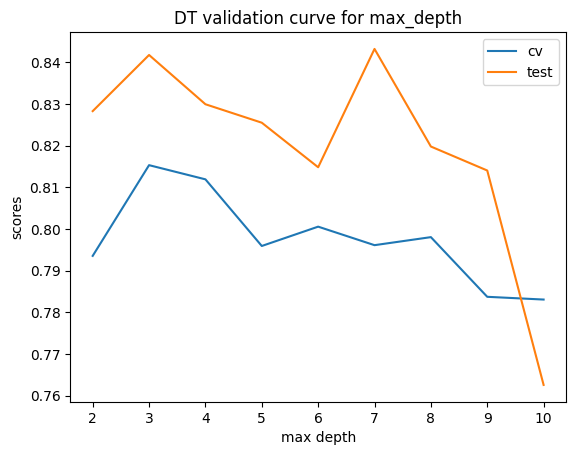

In [ ]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [ ]:
dict_param = {
    "max_depth": [2, 3, 5, 7, 10, 20],
    "min_samples_leaf": [5, 10, 20, 50, 100],
    "criterion": ["gini", "entropy"]
}
best_tree = grid_search("decision-tree", n_jobs=-1, dict_param=dict_param)

Best model: DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)


### Bài 2: đánh giá best_tree
- Prediction performance
- Learning curve

Evaluation of Best Decision Tree
Train Accuracy : 0.77125
Train f1 score : 0.8473728106755629
Train roc auc : 0.680523905314024
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8533333333333334
Test roc auc : 0.6911888448130785


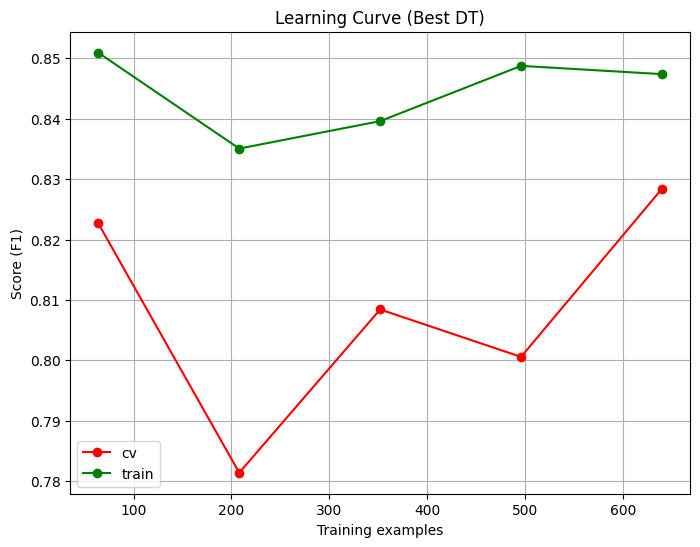

In [ ]:
print("Evaluation of Best Decision Tree")
evaluate(best_tree)
plt.figure(figsize=(8, 6))
plot_learning_curve(best_tree, "Learning Curve (Best DT)", {"train": "train", "test": "cv"}, X_train, y_train, cv=5, new_plot=True)
plt.show()

Top 10 feature importances
Feature  0 - 0.40445005922715943
Feature  1 - 0.17066428015343657
Feature  2 - 0.14261352910286315
Feature  3 - 0.07120344185816782
Feature  4 - 0.05428847945598893
Feature  5 - 0.05400258515142507
Feature  6 - 0.04007488290946428
Feature  7 - 0.03813781829612112
Feature  8 - 0.015091674891623292
Feature  9 - 0.009473248953750433


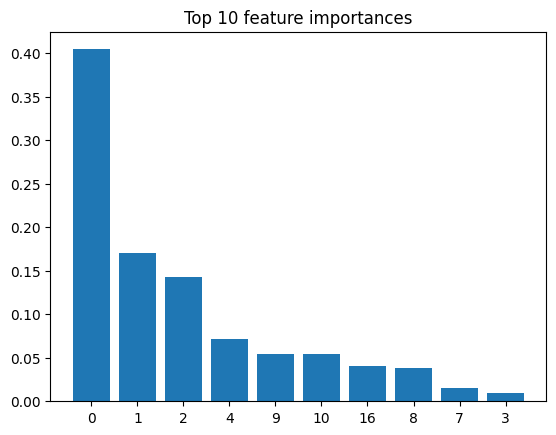

In [ ]:
# Nhận xét về độ quan trọng của từng feature
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()

###  3.2 Random Forest

### Bài 3: thực hành tương tự với RF

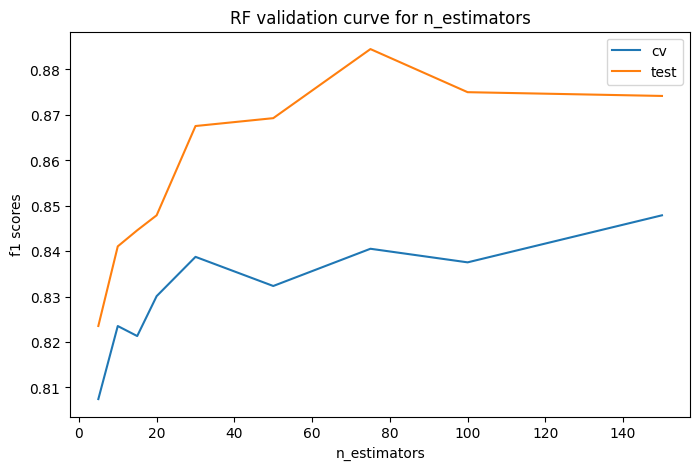

In [ ]:
cv_accuracies_by_n, test_accuracies_by_n = [], []
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]

for n in num_trees:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=random_state)
    # cross-validation
    val_scores = cross_val_score(estimator=rf_temp, X=X_train, y=y_train, cv=5, scoring='f1')
    cv_accuracies_by_n.append(val_scores.mean())

    # test
    rf_temp.fit(X_train, y_train)
    curr_pred = rf_temp.predict(X_test)
    test_accuracies_by_n.append(f1_score(y_test, curr_pred))

plt.figure(figsize=(8, 5))
plt.plot(num_trees, cv_accuracies_by_n, label='cv')
plt.plot(num_trees, test_accuracies_by_n, label='test')
plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('f1 scores')
plt.title('RF validation curve for n_estimators')
plt.show()

In [ ]:
dict_param_rf = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features': [4, 6, 10, 16],
    'n_estimators': [75]
}
print("Searching for Best Random Forest...")
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param_rf)

Searching for Best Random Forest...
Best model: RandomForestClassifier(max_depth=11, max_features=6, n_estimators=75,
                       random_state=42)


Evaluation of Best Random Forest
Train Accuracy : 0.98875
Train f1 score : 0.9920141969831411
Train roc auc : 0.9813278008298756
--------------------------------------------------
Test Accuracy : 0.79
Test f1 score : 0.86
Test roc auc : 0.7032095203750451


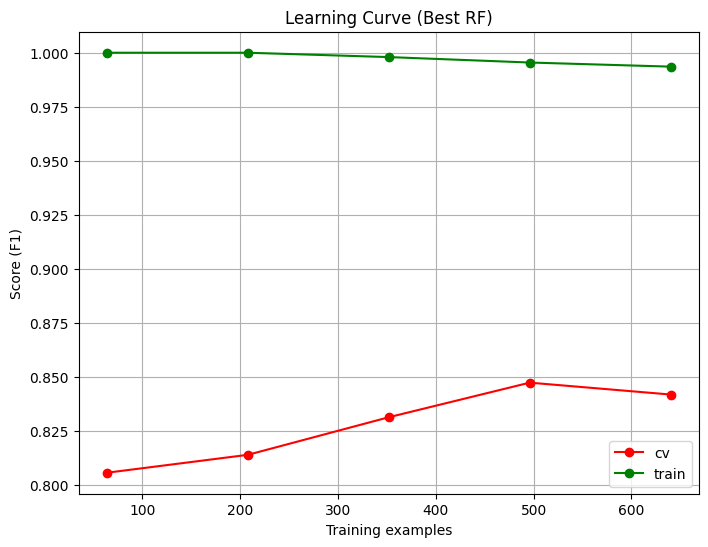

In [ ]:
print("Evaluation of Best Random Forest")
evaluate(best_forest)
plt.figure(figsize=(8, 6))
plot_learning_curve(best_forest, "Learning Curve (Best RF)", {"train": "train", "test": "cv"}, X_train, y_train, cv=5, new_plot=True)
plt.show()

Top 10 Feature Importances (Random Forest)
Feature 3: 0.1393
Feature 0: 0.1176
Feature 9: 0.1165
Feature 1: 0.1016
Feature 2: 0.0749
Feature 5: 0.0592
Feature 8: 0.0498
Feature 4: 0.0456
Feature 7: 0.0422
Feature 6: 0.0367


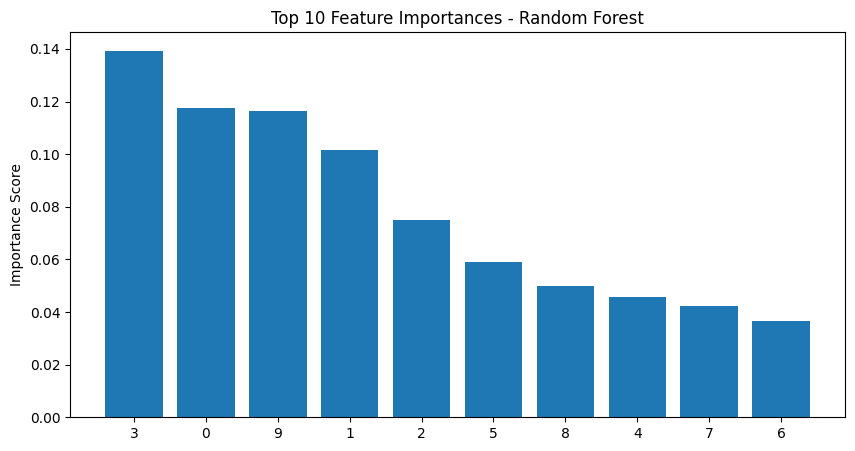

In [ ]:
importances_rf = best_forest.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

print('Top 10 Feature Importances (Random Forest)')
for i in range(10):
    print(f"Feature {indices_rf[i]}: {importances_rf[indices_rf[i]]:.4f}")

plt.figure(figsize=(10, 5))
plt.title('Top 10 Feature Importances - Random Forest')
plt.bar(range(10), importances_rf[indices_rf[:10]])
plt.xticks(range(10), indices_rf[:10])
plt.ylabel('Importance Score')
plt.show()

### 3.3 Thử nghiệm bổ sung

#### 3.3.1 Bỏ một số features có độ quan trọng thấp

In [ ]:
# Thử bỏ một sô feature có độ quan trọng thấp đi
# Chú ý tham max_features cần thay đổi
sfm = SelectFromModel(best_forest, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)

title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test':'cv'}
forest_dropped = RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       n_estimators=75, n_jobs=-1, random_state=random_state)

# plot_learning_curve(forest_dropped, title, label_curve, X_train_dropped, y_train, cv=5)

forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)
print('acc', accuracy_score(y_test, y_dropped_pred))
print('f1', f1_score(y_test, y_dropped_pred))
print('roc_auc', roc_auc_score(y_test, y_dropped_pred))

acc 0.805
f1 0.8737864077669902
roc_auc 0.6990623873061665


#### 3.3.2 Một số chiến lược áp dụng cho Random Forest khi gặp phải Class Imbalance
https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/

In [ ]:
'''
- Standard RF
'''
params = {
    'max_depth': best_forest.get_params()['max_depth'],
    'max_features': best_forest.get_params()['max_features'],
    'min_samples_leaf': best_forest.get_params()['min_samples_leaf'],
    'n_estimators': best_forest.get_params()['n_estimators'],
}
evaluate(best_forest)


Train Accuracy : 0.98875
Train f1 score : 0.9920141969831411
Train roc auc : 0.9813278008298756
--------------------------------------------------
Test Accuracy : 0.79
Test f1 score : 0.86
Test roc auc : 0.7032095203750451


In [ ]:
'''
- Random Forest With Class Weighting
'''
rf1 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced')
rf1.fit(X_train, y_train)
evaluate(rf1)

Train Accuracy : 0.99125
Train f1 score : 0.9937332139659804
Train roc auc : 0.9901981160786526
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8523489932885906
Test roc auc : 0.6961173217934847


In [ ]:
'''
- Random Forest With Bootstrap Class Weighting
'''
'''
- Random Forest With Class Weighting
'''
rf2 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced_subsample')
rf2.fit(X_train, y_train)
evaluate(rf2)

Train Accuracy : 0.995
Train f1 score : 0.996415770609319
Train roc auc : 0.99524194805484
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8513513513513513
Test roc auc : 0.701045798773891


In [ ]:
'''
- Random Forest With Random Undersampling
'''
from imblearn.ensemble import BalancedRandomForestClassifier
rf3 = BalancedRandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             )
rf3.fit(X_train, y_train)
evaluate(rf3)

Train Accuracy : 0.965
Train f1 score : 0.9743119266055046
Train roc auc : 0.9749552772808587
--------------------------------------------------
Test Accuracy : 0.755
Test f1 score : 0.8218181818181818
Test roc auc : 0.7227431181632407
